In [1]:
!pip install dagshub mlflow optuna -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from kaggle_secrets import UserSecretsClient
import warnings
warnings.filterwarnings('ignore')

dagshub.init (
    repo_owner="sophyrise",
    repo_name='ieee-cis-fraud-detection',
    mlflow=True
)

mlflow.set_experiment("Decision Trees")
print("✅ MLflow tracking URI:", mlflow.get_tracking_uri())

Accessing as sophyrise

Initialized MLflow to track repo "sophyrise/ieee-cis-fraud-detection"

Repository sophyrise/ieee-cis-fraud-detection initialized!

✅ MLflow tracking URI: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow


# **Cleaning**

In [ ]:
with mlflow.start_run(run_name="DecisionTrees_Cleaning"):
    import gc
    import numpy as np
    import pandas as pd

    DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection"
    TXN_MISSING_THRESHOLD = 0.80
    ID_MISSING_THRESHOLD = 0.95
    NEAR_CONSTANT_THRESHOLD = 0.99

    # load
    train_txn = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
    train_id  = pd.read_csv(f"{DATA_DIR}/train_identity.csv")
    test_txn  = pd.read_csv(f"{DATA_DIR}/test_transaction.csv")
    test_id   = pd.read_csv(f"{DATA_DIR}/test_identity.csv")

    # fix id-01 vs id_01
    test_id.columns = test_id.columns.str.replace("-", "_", regex=False)

    # merge
    train = train_txn.merge(train_id, on="TransactionID", how="left")
    test  = test_txn.merge(test_id, on="TransactionID", how="left")

    del train_txn, train_id, test_txn, test_id
    gc.collect()

    # split target
    y_train = train["isFraud"].astype(np.int8)
    X_train = train.drop(columns=["isFraud", "TransactionID"])
    X_test  = test.drop(columns=["TransactionID"])

    del train, test
    gc.collect()

    # drop high-missing
    id_like_cols = [c for c in X_train.columns if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]]
    txn_like_cols = [c for c in X_train.columns if c not in id_like_cols]
    missing_ratio = X_train.isnull().mean()

    drop_txn = [c for c in txn_like_cols if missing_ratio[c] > TXN_MISSING_THRESHOLD]
    drop_id  = [c for c in id_like_cols if missing_ratio[c] > ID_MISSING_THRESHOLD]
    drop_missing = drop_txn + drop_id

    X_train = X_train.drop(columns=drop_missing)
    X_test  = X_test.drop(columns=[c for c in drop_missing if c in X_test.columns])

    # drop near-constant
    near_constant_cols = []
    for col in X_train.columns:
        top_freq = X_train[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_freq > NEAR_CONSTANT_THRESHOLD:
            near_constant_cols.append(col)

    X_train = X_train.drop(columns=near_constant_cols)
    X_test  = X_test.drop(columns=[c for c in near_constant_cols if c in X_test.columns])

    # align test columns
    for col in X_train.columns:
        if col not in X_test.columns:
            X_test[col] = np.nan
    X_test = X_test[X_train.columns]

    # log
    mlflow.log_param("txn_missing_threshold", TXN_MISSING_THRESHOLD)
    mlflow.log_param("id_missing_threshold", ID_MISSING_THRESHOLD)
    mlflow.log_param("near_constant_threshold", NEAR_CONSTANT_THRESHOLD)

    mlflow.log_metric("train_rows", int(X_train.shape[0]))
    mlflow.log_metric("test_rows", int(X_test.shape[0]))
    mlflow.log_metric("final_features", int(X_train.shape[1]))
    mlflow.log_metric("fraud_rate", float(y_train.mean()))
    mlflow.log_metric("dropped_missing_cols", int(len(drop_missing)))
    mlflow.log_metric("dropped_near_constant_cols", int(len(near_constant_cols)))

    print(f"X_train_clean: {X_train.shape}")
    print(f"X_test_clean:  {X_test.shape}")

    # keep for next cells
    X_train_clean = X_train
    X_test_clean = X_test
    y_train_clean = y_train

# **Feature Engineering**

In [ ]:
with mlflow.start_run(run_name="DecisionTree_FeatureEngineering"):
    from sklearn.impute import SimpleImputer

    X_train = X_train_clean.copy()
    X_test = X_test_clean.copy()
    y_train = y_train_clean.copy()

    X_train["TransactionAmt_log"] = np.log1p(X_train["TransactionAmt"].clip(lower=0))
    X_test["TransactionAmt_log"] = np.log1p(X_test["TransactionAmt"].clip(lower=0))

    X_train["hour_sin"] = np.sin(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_train["hour_cos"] = np.cos(2 * np.pi * ((X_train["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_sin"] = np.sin(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)
    X_test["hour_cos"] = np.cos(2 * np.pi * ((X_test["TransactionDT"] // 3600) % 24) / 24)

    X_train = X_train.drop(columns=["TransactionDT"], errors="ignore")
    X_test = X_test.drop(columns=["TransactionDT"], errors="ignore")

    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    num_imp = SimpleImputer(strategy="median")
    X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
    X_test[num_cols] = num_imp.transform(X_test[num_cols])

    cat_maps = {}
    for c in cat_cols:
        uniq = pd.Series(X_train[c].astype(str).unique())
        mapping = {v: i for i, v in enumerate(uniq)}
        cat_maps[c] = mapping
        X_train[c] = X_train[c].astype(str).map(mapping).fillna(-1).astype(np.int32)
        X_test[c] = X_test[c].astype(str).map(mapping).fillna(-1).astype(np.int32)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=-1)

    mlflow.log_metric("features_after_fe", int(X_train.shape[1]))
    mlflow.log_metric("cat_cols_encoded", int(len(cat_cols)))

    print("X_train_fe:", X_train.shape)
    print("X_test_fe: ", X_test.shape)

    X_train_fe_dt = X_train
    X_test_fe_dt = X_test
    y_train_fe_dt = y_train

In [ ]:
print(X_train_fe_dt.shape, X_test_fe_dt.shape)
assert X_train_fe_dt.shape[1] == X_test_fe_dt.shape[1]
print("object cols left:", X_train_fe_dt.select_dtypes(include=["object"]).shape[1])

# **Feature Selection**

In [ ]:
with mlflow.start_run(run_name="DecisionTree_FeatureSelection"):
    X_train = X_train_fe_dt.copy()
    X_test = X_test_fe_dt.copy()

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    nu = X_train.nunique(dropna=False)
    const_cols = nu[nu <= 1].index.tolist()
    X_train = X_train.drop(columns=const_cols, errors="ignore")
    X_test = X_test.drop(columns=const_cols, errors="ignore")

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    sample_n = min(120_000, len(X_train))
    idx = np.random.RandomState(42).choice(len(X_train), size=sample_n, replace=False)
    corr = X_train.iloc[idx][num_cols].corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    drop_corr = [c for c in upper.columns if (upper[c] > 0.98).any()]

    X_train = X_train.drop(columns=drop_corr, errors="ignore")
    X_test = X_test.drop(columns=drop_corr, errors="ignore")

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    mlflow.log_metric("dropped_const", len(const_cols))
    mlflow.log_metric("dropped_corr", len(drop_corr))
    mlflow.log_metric("features_after_fs", int(X_train.shape[1]))

    print("X_train_fs:", X_train.shape)

    X_train_final_dt = X_train
    X_test_final_dt = X_test

In [ ]:
print(X_train_final_dt.shape, X_test_final_dt.shape)
assert X_train_final_dt.shape[1] == X_test_final_dt.shape[1]

In [ ]:
import pickle, os
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

with open(f"{CHECKPOINT_DIR}/X_train_final_dt.pkl", "wb") as f:
    pickle.dump(X_train_final_dt, f)
with open(f"{CHECKPOINT_DIR}/X_test_final_dt.pkl", "wb") as f:
    pickle.dump(X_test_final_dt, f)
with open(f"{CHECKPOINT_DIR}/y_train_fe_dt.pkl", "wb") as f:
    pickle.dump(y_train_fe_dt, f)

print("✅ Checkpoint saved to", CHECKPOINT_DIR)

In [3]:
import pickle, os

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
CHECKPOINT_EXISTS = all(
    os.path.exists(f"{CHECKPOINT_DIR}/{f}")
    for f in ["X_train_final_dt.pkl", "X_test_final_dt.pkl", "y_train_fe_dt.pkl"]
)

if CHECKPOINT_EXISTS:
    with open(f"{CHECKPOINT_DIR}/X_train_final_dt.pkl", "rb") as f:
        X_train_final_dt = pickle.load(f)
    with open(f"{CHECKPOINT_DIR}/X_test_final_dt.pkl", "rb") as f:
        X_test_final_dt = pickle.load(f)
    with open(f"{CHECKPOINT_DIR}/y_train_fe_dt.pkl", "rb") as f:
        y_train_fe_dt = pickle.load(f)
    print("✅ Loaded from checkpoint — skipped preprocessing")
else:
    print("⚠️  No checkpoint found — run preprocessing cells first")

✅ Loaded from checkpoint — skipped preprocessing


# **Training**

In [4]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final_dt, y_train_fe_dt,
    test_size=0.2, random_state=42, stratify=y_train_fe_dt
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")
print(f"Fraud rate train: {y_tr.mean():.4f}, val: {y_val.mean():.4f}")

Train: (472432, 306), Val: (118108, 306)
Fraud rate train: 0.0350, val: 0.0350


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

with mlflow.start_run(run_name="DT_Baseline"):
    mlflow.log_param("max_depth",    3)
    mlflow.log_param("criterion",    "gini")
    mlflow.log_param("class_weight", None)
    mlflow.log_param("note",         "very shallow tree, no class balancing — expect underfitting")

    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  clf.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
    gap = train_auc - val_auc

    mlflow.log_metric("train_auc",   round(train_auc, 5))
    mlflow.log_metric("val_auc",     round(val_auc,   5))
    mlflow.log_metric("overfit_gap", round(gap, 5))

    print(f"[Baseline] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")
    print(f"  -> UNDERFIT as expected: depth=3, no class balancing")

[Baseline] Train: 0.6914 | Val: 0.6878 | Gap: 0.0037
  -> UNDERFIT as expected: depth=3, no class balancing
🏃 View run DT_Baseline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/a0b6ec31836c48068c9c822b38a09172
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [6]:
# fraud data is heavily imbalanced (3.5% fraud)
# class_weight="balanced" should help significantly
for cw in [None, "balanced"]:
    label = str(cw)
    with mlflow.start_run(run_name=f"DT_classweight_{label}"):
        mlflow.log_param("max_depth",    6)
        mlflow.log_param("criterion",    "gini")
        mlflow.log_param("class_weight", label)

        clf = DecisionTreeClassifier(max_depth=6, class_weight=cw, random_state=42)
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))

        print(f"  class_weight={label:<10} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

# balanced is expected to win on fraud data — set it
best_class_weight = "balanced"

  class_weight=None       | Train: 0.7967 | Val: 0.7929 | Gap: 0.0038
🏃 View run DT_classweight_None at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/2ff998b33a394461a6db0bf356ff8431
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  class_weight=balanced   | Train: 0.8405 | Val: 0.8372 | Gap: 0.0033
🏃 View run DT_classweight_balanced at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/d6465b6aab6945cca020e8a97909449a
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [7]:
depth_results = []
for depth in [3, 5, 10, 15, 20, None]:
    label = str(depth)
    with mlflow.start_run(run_name=f"DT_depth_{label}"):
        mlflow.log_param("max_depth",    label)
        mlflow.log_param("criterion",    "gini")
        mlflow.log_param("class_weight", best_class_weight)

        clf = DecisionTreeClassifier(
            max_depth=depth,
            class_weight=best_class_weight,
            random_state=42
        )
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))
        mlflow.log_metric("n_leaves",    int(clf.get_n_leaves()))

        if gap < 0.01:
            diagnosis = "UNDERFIT — model too shallow"
        elif gap > 0.05:
            diagnosis = "OVERFIT — model memorising train set"
        else:
            diagnosis = "OK"

        depth_results.append({"max_depth": label, "train_auc": train_auc,
                               "val_auc": val_auc, "gap": gap})
        print(f"  depth={label:<5} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f} — {diagnosis}")

depth_df = pd.DataFrame(depth_results).set_index("max_depth")
best_depth_label = depth_df["val_auc"].idxmax()
best_depth_val   = None if best_depth_label == "None" else int(best_depth_label)
print(f"\n-> Best depth: {best_depth_label}")
print(depth_df.to_string())

  depth=3     | Train: 0.7737 | Val: 0.7761 | Gap: -0.0024 — UNDERFIT — model too shallow
🏃 View run DT_depth_3 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/16937b9f0c364d05bec503084e9e387e
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=5     | Train: 0.8238 | Val: 0.8238 | Gap: 0.0000 — UNDERFIT — model too shallow
🏃 View run DT_depth_5 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/954eeaf9f9c944c79075303a3d6478ee
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=10    | Train: 0.8871 | Val: 0.8612 | Gap: 0.0259 — OK
🏃 View run DT_depth_10 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/ecfd3057bd4e47a69403bd0089f58f09
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  depth=15    | Train: 0.9368 |

In [8]:
crit_results = []
for criterion in ["gini", "entropy"]:
    with mlflow.start_run(run_name=f"DT_criterion_{criterion}"):
        mlflow.log_param("max_depth",    best_depth_val)
        mlflow.log_param("criterion",    criterion)
        mlflow.log_param("class_weight", best_class_weight)

        clf = DecisionTreeClassifier(
            max_depth=best_depth_val,
            criterion=criterion,
            class_weight=best_class_weight,
            random_state=42
        )
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))

        crit_results.append({"criterion": criterion, "val_auc": val_auc})
        print(f"  criterion={criterion:<10} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

crit_df = pd.DataFrame(crit_results).set_index("criterion")
best_criterion = crit_df["val_auc"].idxmax()
print(f"\n-> Best criterion: {best_criterion}")

  criterion=gini       | Train: 0.8871 | Val: 0.8612 | Gap: 0.0259
🏃 View run DT_criterion_gini at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/87b2caac268540a9871816e0a610bb52
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  criterion=entropy    | Train: 0.8905 | Val: 0.8593 | Gap: 0.0312
🏃 View run DT_criterion_entropy at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/0872b26fe32a43c68c67299d54ce8ccd
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2

-> Best criterion: gini


In [9]:
# min_samples_leaf controls overfitting at the leaf level
# more effective than depth alone for noisy data
reg_results = []
for min_samples in [1, 10, 50, 100, 500]:
    with mlflow.start_run(run_name=f"DT_minsamples_{min_samples}"):
        mlflow.log_param("max_depth",         best_depth_val)
        mlflow.log_param("criterion",         best_criterion)
        mlflow.log_param("class_weight",      best_class_weight)
        mlflow.log_param("min_samples_leaf",  min_samples)

        clf = DecisionTreeClassifier(
            max_depth=best_depth_val,
            criterion=best_criterion,
            class_weight=best_class_weight,
            min_samples_leaf=min_samples,
            random_state=42
        )
        clf.fit(X_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  clf.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
        gap = train_auc - val_auc

        mlflow.log_metric("train_auc",   round(train_auc, 5))
        mlflow.log_metric("val_auc",     round(val_auc,   5))
        mlflow.log_metric("overfit_gap", round(gap, 5))
        mlflow.log_metric("n_leaves",    int(clf.get_n_leaves()))

        reg_results.append({"min_samples_leaf": min_samples,
                             "train_auc": train_auc, "val_auc": val_auc, "gap": gap})
        print(f"  min_samples_leaf={min_samples:<5} | Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")

reg_df = pd.DataFrame(reg_results).set_index("min_samples_leaf")
best_min_samples = int(reg_df["val_auc"].idxmax())
print(f"\n-> Best min_samples_leaf: {best_min_samples}")
print(reg_df.to_string())

  min_samples_leaf=1     | Train: 0.8871 | Val: 0.8612 | Gap: 0.0259
🏃 View run DT_minsamples_1 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/15ffd34f0b4b4acbb98e46ca2683b24a
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  min_samples_leaf=10    | Train: 0.8867 | Val: 0.8629 | Gap: 0.0238
🏃 View run DT_minsamples_10 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/7e295365acdf487dbbe4900aaa663ea5
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  min_samples_leaf=50    | Train: 0.8844 | Val: 0.8647 | Gap: 0.0198
🏃 View run DT_minsamples_50 at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/eb9952d661604fc0a98b3052c097557e
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2
  min_samples_leaf=100   | Train: 0.8829 | Val: 0.

In [10]:
sample_idx = np.random.RandomState(42).choice(len(X_train_final_dt), size=150_000, replace=False)
X_cv = X_train_final_dt.iloc[sample_idx]
y_cv = y_train_fe_dt.iloc[sample_idx]

with mlflow.start_run(run_name="DT_CrossValidation_5fold"):
    mlflow.log_param("max_depth",        best_depth_val)
    mlflow.log_param("criterion",        best_criterion)
    mlflow.log_param("class_weight",     best_class_weight)
    mlflow.log_param("min_samples_leaf", best_min_samples)
    mlflow.log_param("cv_folds",         5)
    mlflow.log_param("cv_sample_size",   150_000)

    clf_cv = DecisionTreeClassifier(
        max_depth=best_depth_val,
        criterion=best_criterion,
        class_weight=best_class_weight,
        min_samples_leaf=best_min_samples,
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf_cv, X_cv, y_cv, cv=cv, scoring="roc_auc")

    for i, score in enumerate(cv_scores):
        mlflow.log_metric("fold_auc", round(score, 5), step=i)

    mlflow.log_metric("cv_mean_auc", round(cv_scores.mean(), 5))
    mlflow.log_metric("cv_std_auc",  round(cv_scores.std(),  5))

    print(f"CV folds: {[round(s, 4) for s in cv_scores]}")
    print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
    print(f"  -> {'STABLE' if cv_scores.std() < 0.005 else 'HIGH VARIANCE'}")

CV folds: [np.float64(0.8461), np.float64(0.846), np.float64(0.8435), np.float64(0.8578), np.float64(0.8473)]
Mean: 0.8481 | Std: 0.0050
  -> STABLE
🏃 View run DT_CrossValidation_5fold at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/37db3bda6bbd49f7b60104f7354bc4f0
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


In [11]:
import pickle
from sklearn.pipeline import Pipeline

with mlflow.start_run(run_name="DT_Final_Pipeline") as run:
    mlflow.log_param("max_depth",        best_depth_val)
    mlflow.log_param("criterion",        best_criterion)
    mlflow.log_param("class_weight",     best_class_weight)
    mlflow.log_param("min_samples_leaf", best_min_samples)
    mlflow.log_param("note",             "best params from all sweeps, honest val holdout")

    final_pipe = Pipeline([
        ("clf", DecisionTreeClassifier(
            max_depth=best_depth_val,
            criterion=best_criterion,
            class_weight=best_class_weight,
            min_samples_leaf=best_min_samples,
            random_state=42
        ))
    ])

    final_pipe.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  final_pipe.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, final_pipe.predict_proba(X_val)[:, 1])
    gap = train_auc - val_auc

    mlflow.log_metric("train_auc",   round(train_auc, 5))
    mlflow.log_metric("val_auc",     round(val_auc,   5))
    mlflow.log_metric("overfit_gap", round(gap, 5))

    mlflow.sklearn.log_model(
        sk_model=final_pipe,
        artifact_path="decision_tree_pipeline",
        registered_model_name="DecisionTree_FraudDetection"
    )

    pkl_path = "/kaggle/working/decision_tree_final_pipeline.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump(final_pipe, f)
    mlflow.log_artifact(pkl_path)

    print(f"[Final] Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {gap:.4f}")
    print(f"  -> {'OVERFIT' if gap > 0.05 else 'OK'}")
    print(f"Run ID: {run.info.run_id}")
    print("✅ Registered as DecisionTree_FraudDetection")

2026/05/03 10:02:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 10:02:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'DecisionTree_FraudDetection' already exists. Creating a new version of this model...
2026/05/03 10:02:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: DecisionTree_FraudDetection, version 3
Created version '3' of model 'DecisionTree_FraudDetection'.


[Final] Train: 0.8829 | Val: 0.8667 | Gap: 0.0163
  -> OK
Run ID: 3dea524ac2f9434690c2eb6774542a7e
✅ Registered as DecisionTree_FraudDetection
🏃 View run DT_Final_Pipeline at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2/runs/3dea524ac2f9434690c2eb6774542a7e
🧪 View experiment at: https://dagshub.com/sophyrise/ieee-cis-fraud-detection.mlflow/#/experiments/2


# Graph and Pictures

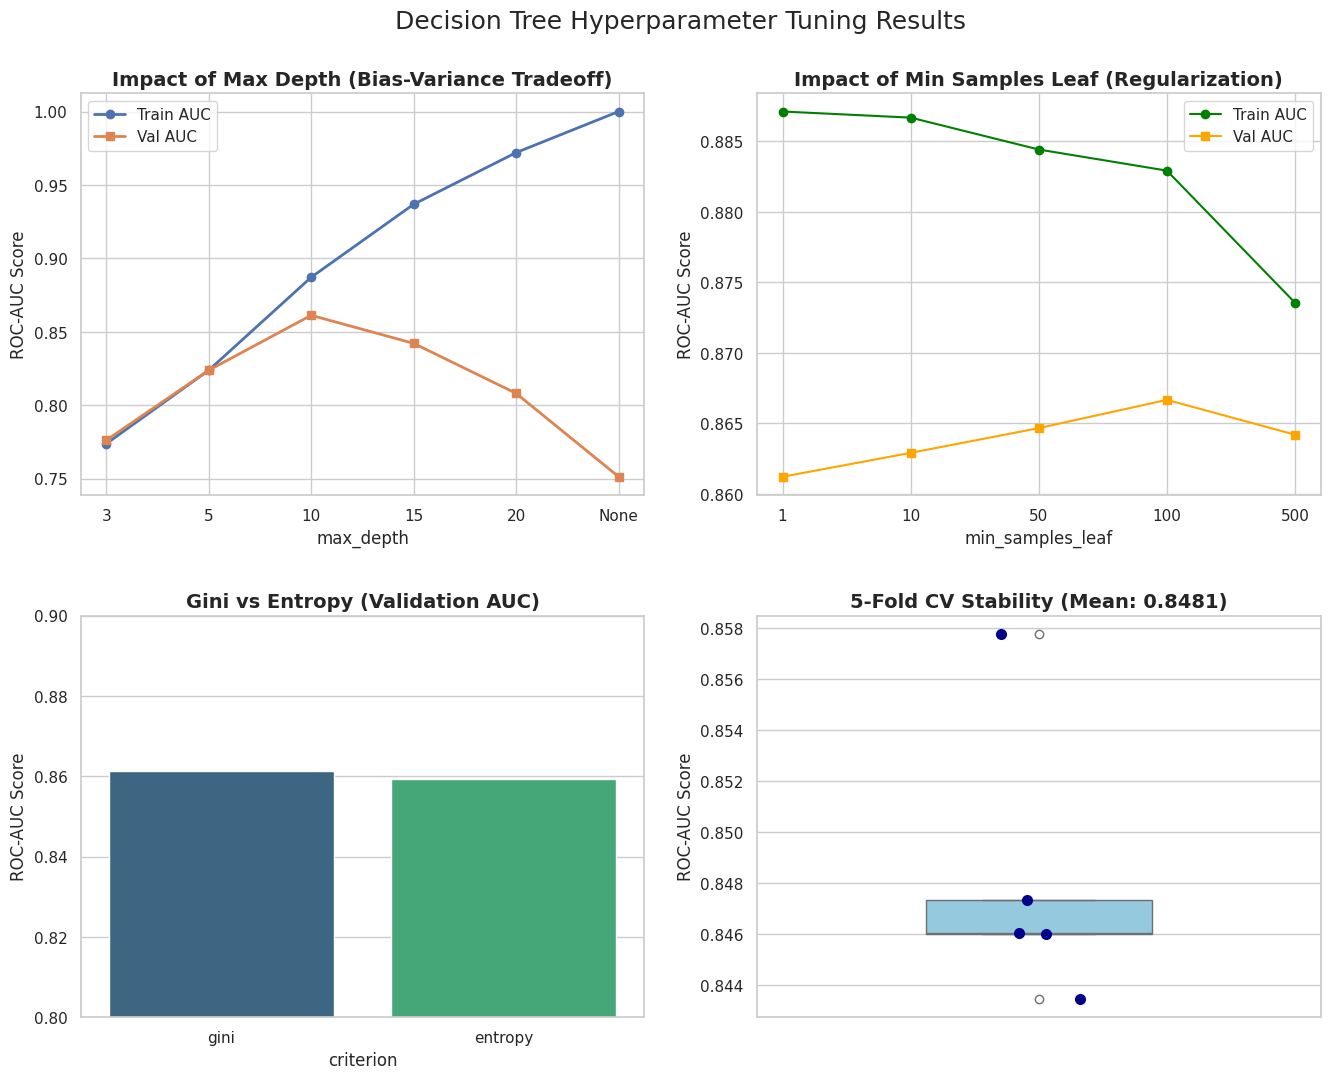

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# 1. Max Depth Analysis (Bias-Variance Tradeoff)
# We convert index to string to handle the 'None' value correctly on the X-axis
plot_depth_df = depth_df.copy()
plot_depth_df.index = plot_depth_df.index.map(str)

axes[0, 0].plot(plot_depth_df.index, plot_depth_df['train_auc'], marker='o', label='Train AUC', linewidth=2)
axes[0, 0].plot(plot_depth_df.index, plot_depth_df['val_auc'], marker='s', label='Val AUC', linewidth=2)
axes[0, 0].set_title('Impact of Max Depth (Bias-Variance Tradeoff)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('max_depth')
axes[0, 0].set_ylabel('ROC-AUC Score')
axes[0, 0].legend()

# 2. Regularization Analysis (min_samples_leaf)
axes[0, 1].plot(reg_df.index.map(str), reg_df['train_auc'], marker='o', label='Train AUC', color='green')
axes[0, 1].plot(reg_df.index.map(str), reg_df['val_auc'], marker='s', label='Val AUC', color='orange')
axes[0, 1].set_title('Impact of Min Samples Leaf (Regularization)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('min_samples_leaf')
axes[0, 1].set_ylabel('ROC-AUC Score')
axes[0, 1].legend()

# 3. Criterion Comparison
sns.barplot(x=crit_df.index, y=crit_df['val_auc'], ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Gini vs Entropy (Validation AUC)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim(0.8, 0.9)  # Zoomed in to see the difference
axes[1, 0].set_ylabel('ROC-AUC Score')

# 4. Cross-Validation Stability
sns.boxplot(y=cv_scores, ax=axes[1, 1], color='skyblue', width=0.4)
sns.stripplot(y=cv_scores, ax=axes[1, 1], color='darkblue', size=8, jitter=True)
axes[1, 1].set_title(f'5-Fold CV Stability (Mean: {np.mean(cv_scores):.4f})', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('ROC-AUC Score')

plt.suptitle("Decision Tree Hyperparameter Tuning Results", fontsize=18, y=0.95)
plt.savefig("tuning_dashboard.png")
plt.show()